In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import torch

mne.set_log_level("WARNING")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.13.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
DATA_DIR = Path(r"G:\SAAD\medical\HUP_iEEG_Project\data\HUP_iEEG_Epilepsy_Dataset")

SUBJECT = "sub-HUP164"
SESSION = "ses-presurgery"

IEEG_DIR = DATA_DIR / SUBJECT / SESSION / "ieeg"

print("Data folder exists:", DATA_DIR.exists())
print("Subject folder exists:", (DATA_DIR / SUBJECT).exists())
print("Session folder exists:", (DATA_DIR / SUBJECT / SESSION).exists())
print("iEEG folder exists:", IEEG_DIR.exists())
print("iEEG path:", IEEG_DIR)

Data folder exists: True
Subject folder exists: True
Session folder exists: True
iEEG folder exists: True
iEEG path: G:\SAAD\medical\HUP_iEEG_Project\data\HUP_iEEG_Epilepsy_Dataset\sub-HUP164\ses-presurgery\ieeg


In [6]:
files = sorted(IEEG_DIR.glob("*"))

for f in files:
    print(f.name)

sub-HUP164_ses-presurgery_acq-seeg_space-fsaverage_coordsystem.json
sub-HUP164_ses-presurgery_acq-seeg_space-fsaverage_electrodes.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01_channels.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01_events.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01_ieeg.edf
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01_ieeg.json
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-02_channels.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-02_events.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-02_ieeg.edf
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-02_ieeg.json
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-03_channels.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-03_events.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-03_ieeg.edf
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-03_ieeg.json
sub-HUP164_ses-presurgery_task-interictal_acq-seeg_run-01_channels.tsv
sub-HUP164_ses-presurgery_task

In [7]:
edf_files = sorted(IEEG_DIR.glob("*.edf"))
tsv_files = sorted(IEEG_DIR.glob("*.tsv"))
json_files = sorted(IEEG_DIR.glob("*.json"))

print("EDF files:")
for f in edf_files:
    print(f.name)

print("\nTSV files:")
for f in tsv_files:
    print(f.name)

print("\nJSON files:")
for f in json_files:
    print(f.name)

EDF files:
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01_ieeg.edf
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-02_ieeg.edf
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-03_ieeg.edf
sub-HUP164_ses-presurgery_task-interictal_acq-seeg_run-01_ieeg.edf
sub-HUP164_ses-presurgery_task-interictal_acq-seeg_run-02_ieeg.edf

TSV files:
sub-HUP164_ses-presurgery_acq-seeg_space-fsaverage_electrodes.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01_channels.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01_events.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-02_channels.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-02_events.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-03_channels.tsv
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-03_events.tsv
sub-HUP164_ses-presurgery_task-interictal_acq-seeg_run-01_channels.tsv
sub-HUP164_ses-presurgery_task-interictal_acq-seeg_run-02_channels.tsv

JSON files:
sub-HUP164_ses-presurgery_acq-seeg_space-fsave

In [8]:
ictal_edfs = sorted(IEEG_DIR.glob("*task-ictal*_ieeg.edf"))
interictal_edfs = sorted(IEEG_DIR.glob("*task-interictal*_ieeg.edf"))

print("Ictal EDF files:")
for f in ictal_edfs:
    print(f.name)

print("\nInterictal EDF files:")
for f in interictal_edfs:
    print(f.name)

Ictal EDF files:
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01_ieeg.edf
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-02_ieeg.edf
sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-03_ieeg.edf

Interictal EDF files:
sub-HUP164_ses-presurgery_task-interictal_acq-seeg_run-01_ieeg.edf
sub-HUP164_ses-presurgery_task-interictal_acq-seeg_run-02_ieeg.edf


## Patient HUP164

### Cell 1: Choose ictal run-01

In [9]:
mne.set_log_level("WARNING")

DATA_DIR = Path(r"G:\SAAD\medical\HUP_iEEG_Project\data\HUP_iEEG_Epilepsy_Dataset")

SUBJECT = "sub-HUP164"
SESSION = "ses-presurgery"

IEEG_DIR = DATA_DIR / SUBJECT / SESSION / "ieeg"

base = "sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01"

edf_path = IEEG_DIR / f"{base}_ieeg.edf"
channels_path = IEEG_DIR / f"{base}_channels.tsv"
events_path = IEEG_DIR / f"{base}_events.tsv"
json_path = IEEG_DIR / f"{base}_ieeg.json"

print("EDF exists:", edf_path.exists())
print("Channels exists:", channels_path.exists())
print("Events exists:", events_path.exists())
print("JSON exists:", json_path.exists())

EDF exists: True
Channels exists: True
Events exists: True
JSON exists: True


In [10]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

channels_df = pd.read_csv(channels_path, sep="\t")
events_df = pd.read_csv(events_path, sep="\t")

with open(json_path, "r") as f:
    metadata = json.load(f)

print("Channels table shape:", channels_df.shape)
display(channels_df.head(20))

print("\nEvents table shape:", events_df.shape)
display(events_df)

print("\nMetadata:")
metadata

Channels table shape: (180, 9)


,name,type,units,low_cutoff,high_cutoff,description,sampling_frequency,status,status_description
0,EKG1,SEEG,µV,0.0,512.0,StereoEEG,1024.0,bad,NaN
1,EKG2,SEEG,µV,0.0,512.0,StereoEEG,1024.0,bad,NaN
2,LA1,SEEG,µV,0.0,512.0,StereoEEG,1024.0,good,soz
3,LA10,SEEG,µV,0.0,512.0,StereoEEG,1024.0,good,NaN
4,LA11,SEEG,µV,0.0,512.0,StereoEEG,1024.0,good,NaN
5,LA12,SEEG,µV,0.0,512.0,StereoEEG,1024.0,good,NaN
6,LA2,SEEG,µV,0.0,512.0,StereoEEG,1024.0,good,soz
7,LA3,SEEG,µV,0.0,512.0,StereoEEG,1024.0,good,soz
8,LA4,SEEG,µV,0.0,512.0,StereoEEG,1024.0,good,NaN
9,LA5,SEEG,µV,0.0,512.0,StereoEEG,1024.0,good,NaN



Events table shape: (2, 5)


,onset,duration,trial_type,value,sample
0,120.000000,0.0,sz onset,2,122880
1,185.999023,0.0,sz offset,1,190463



Metadata:


{'TaskName': 'ictal',
 'Manufacturer': 'n/a',
 'PowerLineFrequency': 60,
 'SamplingFrequency': 1024.0,
 'SoftwareFilters': 'n/a',
 'RecordingDuration': 245.9990234375,
 'RecordingType': 'continuous',
 'iEEGReference': 'n/a',
 'ECOGChannelCount': 0,
 'SEEGChannelCount': 180,
 'EEGChannelCount': 0,
 'EOGChannelCount': 0,
 'ECGChannelCount': 0,
 'EMGChannelCount': 0,
 'MiscChannelCount': 0,
 'TriggerChannelCount': 0}

## extract bad channels and SOZ channels.

In [12]:
# Bad channels
bad_channels = channels_df.loc[
    channels_df["status"].astype(str).str.lower() == "bad",
    "name"
].tolist()

# Seizure onset zone channels
soz_channels = channels_df.loc[
    channels_df["status_description"].astype(str).str.lower().str.contains("soz", na=False),
    "name"
].tolist()

print("Number of bad channels:", len(bad_channels))
print("Bad channels:", bad_channels)

print("\nNumber of SOZ channels:", len(soz_channels))
print("SOZ channels:", soz_channels)

#### seizure-onset channels this patient has.

Number of bad channels: 4
Bad channels: ['EKG1', 'EKG2', 'LD11', 'LD12']

Number of SOZ channels: 9
SOZ channels: ['LA1', 'LA2', 'LA3', 'LB1', 'LB2', 'LB3', 'LC1', 'LC2', 'LC3']


In [13]:
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

print(raw)
print("Number of channels:", len(raw.ch_names))
print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Recording duration:", raw.times[-1], "seconds")
print("Duration in minutes:", raw.times[-1] / 60)

print("\nFirst 30 channel names:")
print(raw.ch_names[:30])

<RawEDF | sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01_ieeg.edf, 180 x 251904 (246.0 s), ~172 KiB, data not loaded>
Number of channels: 180
Sampling frequency: 1024.0 Hz
Recording duration: 245.9990234375 seconds
Duration in minutes: 4.099983723958333

First 30 channel names:
['EKG1', 'EKG2', 'LA1', 'LA10', 'LA11', 'LA12', 'LA2', 'LA3', 'LA4', 'LA5', 'LA6', 'LA7', 'LA8', 'LA9', 'LB1', 'LB10', 'LB11', 'LB12', 'LB2', 'LB3', 'LB4', 'LB5', 'LB6', 'LB7', 'LB8', 'LB9', 'LC1', 'LC10', 'LC11', 'LC12']


## Load data and remove bad channels

In [14]:
raw_plot = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

# Mark bad channels
bad_channels_in_raw = [ch for ch in bad_channels if ch in raw_plot.ch_names]
raw_plot.info["bads"] = bad_channels_in_raw

# Keep only data channels and remove bad channels
raw_plot.pick(picks="data", exclude="bads")

print(raw_plot)
print("Bad channels removed:", bad_channels_in_raw)
print("Remaining channels:", len(raw_plot.ch_names))

<RawEDF | sub-HUP164_ses-presurgery_task-ictal_acq-seeg_run-01_ieeg.edf, 176 x 251904 (246.0 s), ~338.4 MiB, data loaded>
Bad channels removed: ['EKG1', 'EKG2', 'LD11', 'LD12']
Remaining channels: 176


### Plot 1: Signal around seizure onset

##### This will show 20 seconds before seizure and 20 seconds after seizure starts.

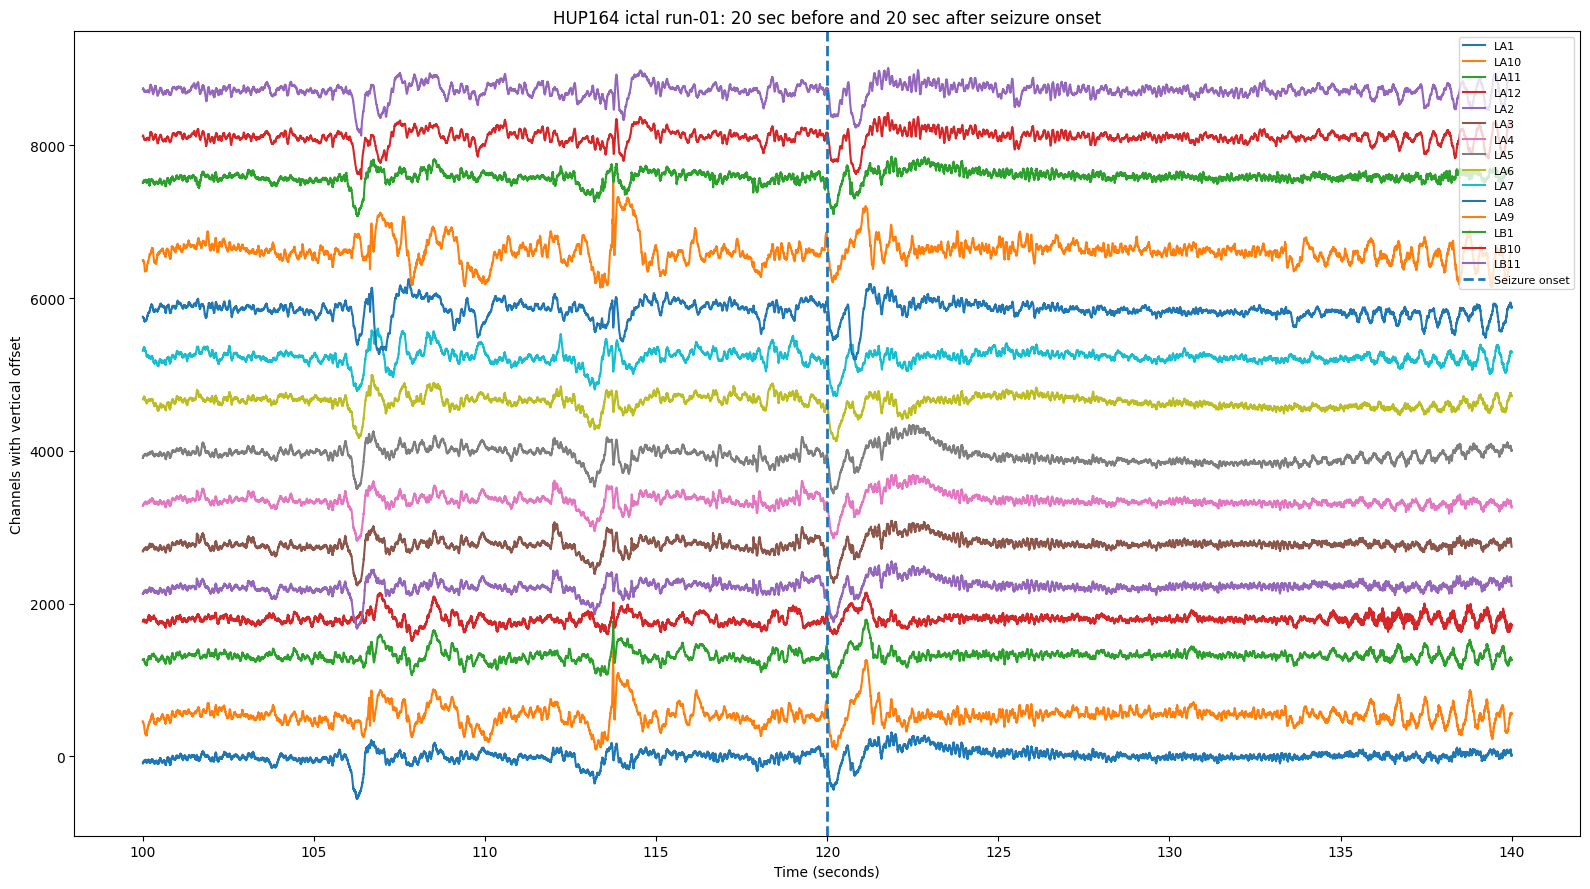

In [15]:
sfreq = raw_plot.info["sfreq"]

start_sec = 100
duration_sec = 40

start_sample = int(start_sec * sfreq)
stop_sample = int((start_sec + duration_sec) * sfreq)

data, times = raw_plot[:15, start_sample:stop_sample]

plt.figure(figsize=(16, 9))

offset = 0
for i in range(data.shape[0]):
    signal = data[i] * 1e6
    signal = signal - np.mean(signal)
    plt.plot(times, signal + offset, label=raw_plot.ch_names[i])
    offset += np.std(signal) * 6

plt.axvline(120, linestyle="--", linewidth=2, label="Seizure onset")
plt.xlabel("Time (seconds)")
plt.ylabel("Channels with vertical offset")
plt.title("HUP164 ictal run-01: 20 sec before and 20 sec after seizure onset")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

### Plot 2: Only SOZ channels

##### This one is more important because it shows the channels where the seizure starts.



SOZ channels available in raw data:
['LA1', 'LA2', 'LA3', 'LB1', 'LB2', 'LB3', 'LC1', 'LC2', 'LC3']


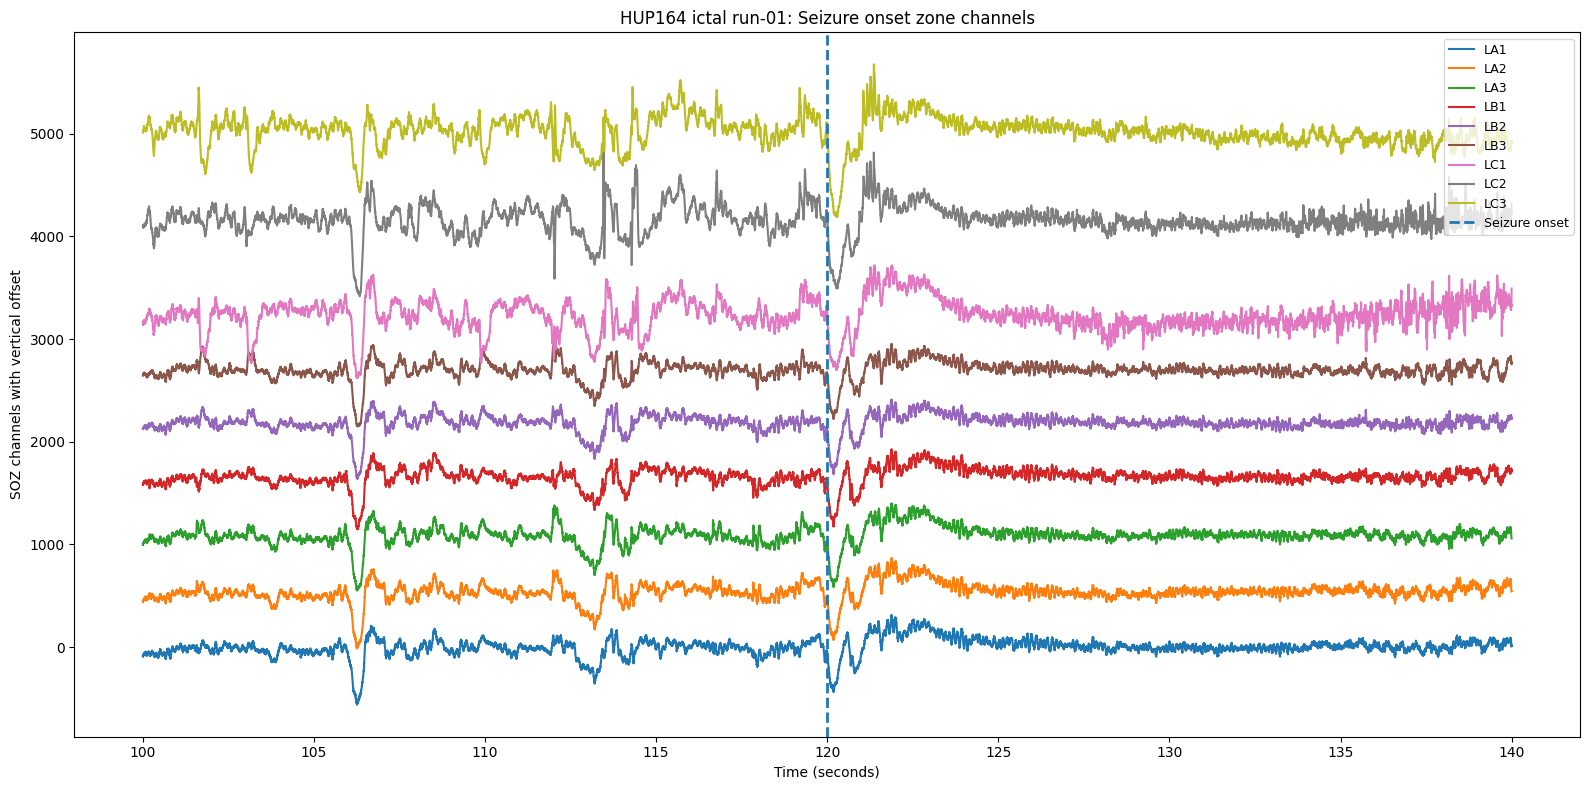

In [17]:
available_soz_channels = [ch for ch in soz_channels if ch in raw_plot.ch_names]

print("SOZ channels available in raw data:")
print(available_soz_channels)

start_sec = 100
duration_sec = 40

start_sample = int(start_sec * sfreq)
stop_sample = int((start_sec + duration_sec) * sfreq)

soz_indices = [raw_plot.ch_names.index(ch) for ch in available_soz_channels]

data, times = raw_plot[soz_indices, start_sample:stop_sample]

plt.figure(figsize=(16, 8))

offset = 0
for i in range(data.shape[0]):
    signal = data[i] * 1e6
    signal = signal - np.mean(signal)
    plt.plot(times, signal + offset, label=available_soz_channels[i])
    offset += np.std(signal) * 6

plt.axvline(120, linestyle="--", linewidth=2, label="Seizure onset")
plt.xlabel("Time (seconds)")
plt.ylabel("SOZ channels with vertical offset")
plt.title("HUP164 ictal run-01: Seizure onset zone channels")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

### Plot 3: Compare before, during, and after seizure

##### This will plot one SOZ channel in three time regions:


Before seizure: 100–120 sec\
During seizure: 120–140 sec\
After seizure starts more: 140–160 sec

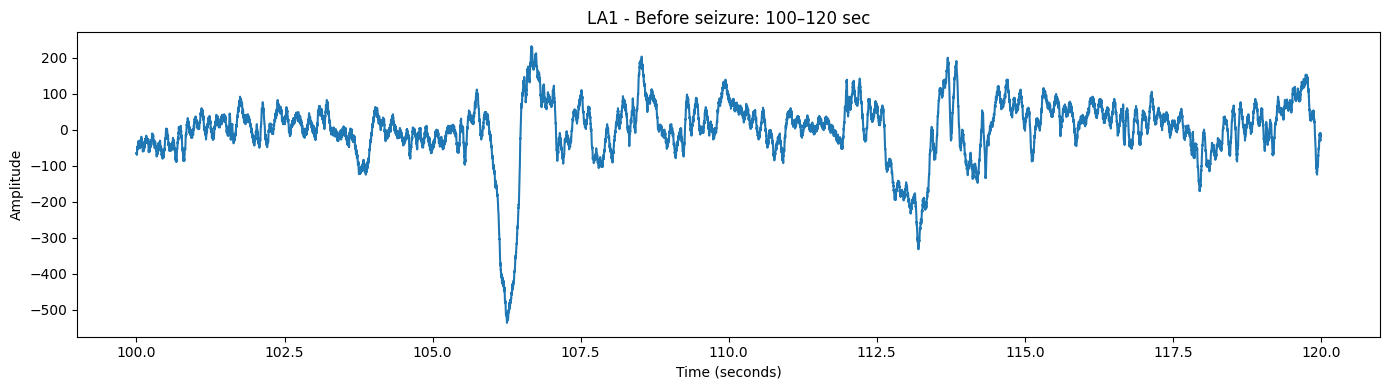

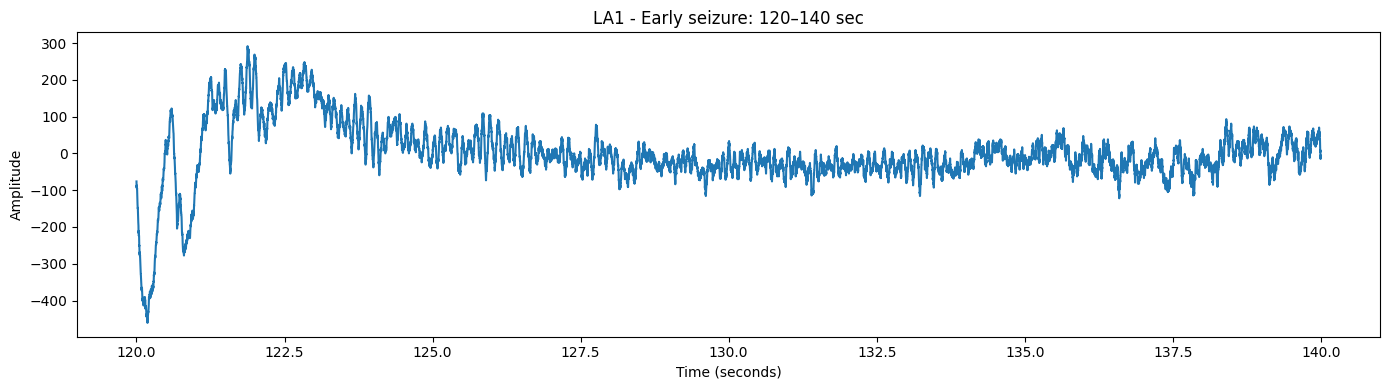

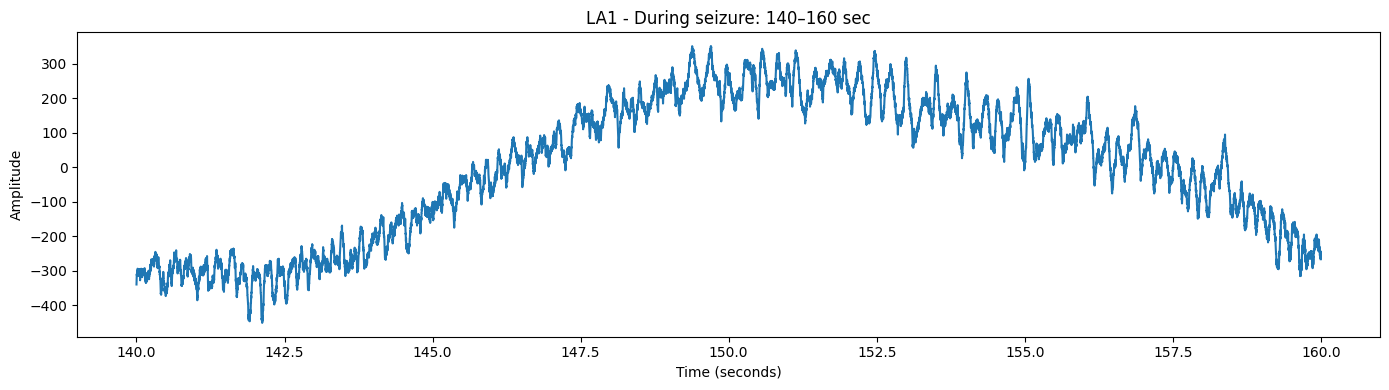

In [18]:
channel_to_plot = available_soz_channels[0]  # first SOZ channel, usually LA1
ch_idx = raw_plot.ch_names.index(channel_to_plot)

segments = {
    "Before seizure: 100–120 sec": (100, 120),
    "Early seizure: 120–140 sec": (120, 140),
    "During seizure: 140–160 sec": (140, 160),
}

for title, (start, stop) in segments.items():
    start_sample = int(start * sfreq)
    stop_sample = int(stop * sfreq)

    data, times = raw_plot[ch_idx, start_sample:stop_sample]
    signal = data[0] * 1e6
    signal = signal - np.mean(signal)

    plt.figure(figsize=(14, 4))
    plt.plot(times, signal)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.title(f"{channel_to_plot} - {title}")
    plt.tight_layout()
    plt.show()

### Visual inspection of HUP164 ictal run-01

The recording contains 180 total channels, with 4 bad channels removed. The seizure onset is marked at 120 seconds and seizure offset is around 186 seconds. The clinically marked seizure onset zone (SOZ) channels are LA1, LA2, LA3, LB1, LB2, LB3, LC1, LC2, and LC3.

Visual inspection shows a clear signal change around the seizure onset time. The SOZ channels show a strong deflection at approximately 120 seconds, followed by increased and more organized rhythmic activity. In channel LA1, the 100–120 sec pre-onset segment contains some sharp transient activity, but the 120–140 sec and 140–160 sec seizure segments show stronger amplitude changes and more rhythmic seizure-like activity.

From visual inspection alone, it is clear that the signal changes after seizure onset. However, it is not yet possible to confidently say whether SOZ channels change earlier than non-SOZ channels. Quantitative feature extraction is needed to compare SOZ and non-SOZ channels across time.

## Visual Interpretation of HUP164 Ictal Run-01

The seizure onset is marked at **120 seconds**. Based on the plots, we visually inspected the signal before and after seizure onset, especially in the seizure onset zone (SOZ) channels.

### 1. Does the signal become more rhythmic after 120 seconds?

Yes, especially after the seizure begins.

In the separate LA1 channel plots:

- Before seizure, from **100–120 seconds**, the signal shows some sharp spikes and irregular activity.
- From **120–140 seconds**, there is a strong onset deflection and faster activity.
- From **140–160 seconds**, the signal becomes more organized and rhythmic, with a large slow wave-like pattern.

So visually, the signal becomes more seizure-like and more rhythmic after seizure onset.

### 2. Does the amplitude increase?

Yes.

The SOZ channels show a strong amplitude change around **120 seconds**. The LA1 channel also shows larger activity during the seizure period, especially from **140–160 seconds**.

This suggests that seizure activity is stronger than the pre-seizure period.

### 3. Do SOZ channels change earlier than non-SOZ channels?

We cannot say confidently from these plots alone.

The SOZ channels clearly change at seizure onset, but the first plot also shows changes in nearby non-SOZ channels. This could mean:

- the seizure spreads quickly,
- the channels are close to the onset zone,
- or some changes are common/reference-related.

To answer this properly, we need to calculate numerical features for SOZ channels and non-SOZ channels over time.

### 4. Is there a clear pattern before seizure onset?

There are some pre-onset sharp events, but no clear sustained pattern yet.

Before **120 seconds**, noticeable sharp changes appear around approximately:

- **106 seconds**
- **113–115 seconds**

However, this does not yet prove a real pre-ictal pattern. These events may be interictal spikes, artifacts, or early abnormal activity.

Therefore, quantitative feature extraction is needed across the full **0–120 second** period to confirm whether a reliable pre-seizure pattern exists.

### Visual plots are good, but for research we need numbers like:

RMS amplitude
peak-to-peak amplitude
line length
band power
gamma power
high-gamma power

These features will help us prove whether the signal changes before/during seizure.

### define seizure regions

In [20]:
# Extract seizure onset and offset from events table
seizure_onset = float(events_df.loc[
    events_df["trial_type"].astype(str).str.lower().str.contains("onset"),
    "onset"
].iloc[0])

seizure_offset = float(events_df.loc[
    events_df["trial_type"].astype(str).str.lower().str.contains("offset"),
    "onset"
].iloc[0])

recording_end = raw_plot.times[-1]

print("Seizure onset:", seizure_onset)
print("Seizure offset:", seizure_offset)
print("Recording end:", recording_end)

regions = pd.DataFrame([
    ["early_before", 0, 60, "Before seizure, early baseline within ictal file"],
    ["preictal_candidate", 60, seizure_onset, "Last 60 seconds before seizure onset"],
    ["early_ictal", seizure_onset, 140, "First 20 seconds after seizure onset"],
    ["middle_ictal", 140, 160, "Middle seizure period"],
    ["late_ictal", 160, seizure_offset, "Late seizure period"],
    ["post_ictal", seizure_offset, recording_end, "After seizure offset"],
], columns=["region", "start_sec", "end_sec", "description"])

display(regions)

Seizure onset: 120.0
Seizure offset: 185.9990234375
Recording end: 245.9990234375


,region,start_sec,end_sec,description
0,early_before,0.000000,60.000000,"Before seizure, early baseline within ictal file"
1,preictal_candidate,60.000000,120.000000,Last 60 seconds before seizure onset
2,early_ictal,120.000000,140.000000,First 20 seconds after seizure onset
3,middle_ictal,140.000000,160.000000,Middle seizure period
4,late_ictal,160.000000,185.999023,Late seizure period
5,post_ictal,185.999023,245.999023,After seizure offset


### calculate features for each region

In [21]:
from scipy.signal import welch

def calculate_bandpower(signal, sfreq, low, high):
    freqs, psd = welch(signal, fs=sfreq, nperseg=min(len(signal), int(4 * sfreq)))
    mask = (freqs >= low) & (freqs <= high)
    return np.trapz(psd[mask], freqs[mask])

def extract_features_for_region(raw_obj, channels, start_sec, end_sec, soz_channels):
    sfreq = raw_obj.info["sfreq"]
    start_sample = int(start_sec * sfreq)
    end_sample = int(end_sec * sfreq)

    picks = [raw_obj.ch_names.index(ch) for ch in channels if ch in raw_obj.ch_names]
    selected_channels = [raw_obj.ch_names[p] for p in picks]

    data, times = raw_obj[picks, start_sample:end_sample]

    # Convert to microvolts
    data_uv = data * 1e6

    rows = []

    for i, ch in enumerate(selected_channels):
        x = data_uv[i]
        x = x - np.mean(x)

        rms = np.sqrt(np.mean(x ** 2))
        ptp = np.ptp(x)
        std = np.std(x)
        line_length = np.mean(np.abs(np.diff(x)))

        delta_power = calculate_bandpower(x, sfreq, 1, 4)
        theta_power = calculate_bandpower(x, sfreq, 4, 8)
        alpha_power = calculate_bandpower(x, sfreq, 8, 13)
        beta_power = calculate_bandpower(x, sfreq, 13, 30)
        gamma_power = calculate_bandpower(x, sfreq, 30, 80)
        high_gamma_power = calculate_bandpower(x, sfreq, 80, 150)

        rows.append({
            "channel": ch,
            "is_soz": ch in soz_channels,
            "rms_uv": rms,
            "peak_to_peak_uv": ptp,
            "std_uv": std,
            "line_length_uv": line_length,
            "delta_power": delta_power,
            "theta_power": theta_power,
            "alpha_power": alpha_power,
            "beta_power": beta_power,
            "gamma_power": gamma_power,
            "high_gamma_power": high_gamma_power,
        })

    return pd.DataFrame(rows)

### make the feature table

In [22]:
all_features = []

good_channels = raw_plot.ch_names

for _, row in regions.iterrows():
    region_features = extract_features_for_region(
        raw_obj=raw_plot,
        channels=good_channels,
        start_sec=row["start_sec"],
        end_sec=row["end_sec"],
        soz_channels=soz_channels
    )

    region_features["region"] = row["region"]
    region_features["start_sec"] = row["start_sec"]
    region_features["end_sec"] = row["end_sec"]

    all_features.append(region_features)

features_df = pd.concat(all_features, ignore_index=True)

display(features_df.head())
print("Feature table shape:", features_df.shape)

C:\Users\gohar\AppData\Local\Temp\ipykernel_23576\1371445648.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])
C:\Users\gohar\AppData\Local\Temp\ipykernel_23576\1371445648.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])
C:\Users\gohar\AppData\Local\Temp\ipykernel_23576\1371445648.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])
C:\Users\gohar\AppData\Local\Temp\ipykernel_23576\1371445648.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])
C:\Users\gohar\AppDa

,channel,is_soz,rms_uv,peak_to_peak_uv,std_uv,line_length_uv,delta_power,theta_power,alpha_power,beta_power,gamma_power,high_gamma_power,region,start_sec,end_sec
0,LA1,True,82.772193,631.723507,82.772193,2.905172,2022.696911,702.173007,133.518105,26.810850,18.751726,0.783608,early_before,0.0,60.0
1,LA10,False,147.126653,1579.308766,147.126653,2.312261,7824.872520,1240.286350,313.082166,171.260198,24.600471,1.577159,early_before,0.0,60.0
2,LA11,False,89.817806,860.608835,89.817806,1.973671,3163.427619,718.984834,188.816706,71.215852,15.288302,1.189199,early_before,0.0,60.0
3,LA12,False,82.477318,773.632410,82.477318,2.839953,2342.346031,616.888145,136.631428,36.826266,19.471838,0.661379,early_before,0.0,60.0
4,LA2,True,83.899671,657.663844,83.899671,2.780918,2139.720767,737.312172,142.125369,35.799882,18.715865,0.850114,early_before,0.0,60.0


Feature table shape: (1056, 15)


### compare SOZ vs non-SOZ

In [24]:
feature_summary = features_df.groupby(["region", "is_soz"])[[
    "rms_uv",
    "peak_to_peak_uv",
    "std_uv",
    "line_length_uv",
    "gamma_power",
    "high_gamma_power"
]].mean().reset_index()

display(feature_summary)

,region,is_soz,rms_uv,peak_to_peak_uv,std_uv,line_length_uv,gamma_power,high_gamma_power
0,early_before,False,114.577185,930.654141,114.577185,2.966131,28.565356,1.642186
1,early_before,True,110.188197,898.756390,110.188197,3.099225,33.140972,3.651648
2,early_ictal,False,96.899771,811.588085,96.899771,3.435522,34.532801,2.969022
3,early_ictal,True,103.585756,933.173961,103.585756,3.860012,89.895095,9.216658
4,late_ictal,False,168.787566,1074.408747,168.787566,7.297023,181.557401,28.037945
5,late_ictal,True,142.534153,848.910252,142.534153,5.981364,61.059300,11.488038
6,middle_ictal,False,114.450184,675.654870,114.450184,4.223933,47.387313,5.634741
7,middle_ictal,True,144.566852,710.222697,144.566852,4.488691,98.528334,12.870646
8,post_ictal,False,173.327788,1106.123756,173.327788,5.092488,53.787482,10.610478
9,post_ictal,True,112.098148,836.872579,112.098148,4.200397,28.372970,3.951511


## Quantitative Feature Interpretation

After visual inspection, numerical features were extracted from SOZ and non-SOZ channels across different seizure-related regions.

The most important observation is that the seizure onset zone (SOZ) channels show a strong increase in gamma and high-gamma power after seizure onset. In the SOZ channels, gamma power increases from approximately 36.04 in the preictal candidate region to 89.90 in the early ictal region and 98.53 in the middle ictal region. High-gamma power also increases from approximately 3.65 before seizure onset to 9.22 in early ictal and 12.87 in middle ictal activity.

This supports the visual observation that the SOZ channels become more seizure-like and more rhythmic after the seizure begins at 120 seconds.

Amplitude features show a more complex pattern. RMS amplitude does not increase immediately in the early ictal region, but it becomes higher during the middle and late ictal periods. This suggests that amplitude alone may not be the best marker for early seizure activity. Frequency-domain features such as gamma and high-gamma power appear more informative.

The comparison between SOZ and non-SOZ channels suggests that SOZ channels show stronger high-frequency activity in the early ictal period. Later, during the late ictal period, non-SOZ channels also become highly active, which may indicate seizure spread to other brain regions.

Before seizure onset, the preictal candidate region shows only mild differences compared with the early-before region. Therefore, a strong preictal pattern is not confirmed yet. Smaller sliding-window analysis is needed to investigate whether brief pre-onset changes occur around 106 seconds and 113–115 seconds.